In [1]:
import os
import numpy as np 
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from scipy.stats import skew, kurtosis, median_abs_deviation
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import balanced_accuracy_score, f1_score, average_precision_score

In [2]:
orig_dir = f'{os.getcwd().replace("\\", "/")}/Data/Porcessed Data'
new_dir = f"{os.getcwd().replace("\\", "/")}/Data/Porcessed Data/XGBoost_data"
CNN_train = pd.read_csv(f"{orig_dir}/CNN_train.csv")
CNN_test = pd.read_csv(f'{orig_dir}/CNN_test.csv')
CNN_train.head()

,object_id,Time (MJD),Filter_z_flux,Filter_z_flux_err,Filter_r_flux,Filter_r_flux_err,Filter_y_flux,Filter_y_flux_err,Filter_i_flux,Filter_i_flux_err,...,A_lambda_Filter_r_flux,A_lambda_Filter_r_flux_err,A_lambda_Filter_y_flux,A_lambda_Filter_y_flux_err,A_lambda_Filter_i_flux,A_lambda_Filter_i_flux_err,A_lambda_Filter_g_flux,A_lambda_Filter_g_flux_err,A_lambda_Filter_u_flux,A_lambda_Filter_u_flux_err
0,Dornhoth_fervain_onodrim,63314.4662,-1.895487,0.425312,0.000000,0.000000,-1.601633,1.191244,0.000000,0.000000,...,0.285117,0.285117,0.127223,0.127223,0.209783,0.209783,0.414976,0.414976,0.52232,0.52232
1,Dornhoth_fervain_onodrim,63327.6691,-1.811662,0.462278,0.000000,0.000000,0.000000,0.000000,-1.709337,0.389580,...,0.285117,0.285117,0.127223,0.127223,0.209783,0.209783,0.414976,0.414976,0.52232,0.52232
2,Dornhoth_fervain_onodrim,63340.8720,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-2.495971,0.403594,...,0.285117,0.285117,0.127223,0.127223,0.209783,0.209783,0.414976,0.414976,0.52232,0.52232
3,Dornhoth_fervain_onodrim,63380.4806,0.000000,0.000000,-1.328391,0.225768,0.000000,0.000000,0.000000,0.000000,...,0.285117,0.285117,0.127223,0.127223,0.209783,0.209783,0.414976,0.414976,0.52232,0.52232
4,Dornhoth_fervain_onodrim,63420.0891,0.000000,0.000000,-1.396016,0.576872,0.000000,0.000000,0.000000,0.000000,...,0.285117,0.285117,0.127223,0.127223,0.209783,0.209783,0.414976,0.414976,0.52232,0.52232


In [3]:
f"{orig_dir}/CNN_train.csv"

'd:/Senior Project/Mallorn version 2/Data/Porcessed Data/CNN_train.csv'

In [4]:
main_cols = {
    "dt": "sum",
    "SpecType": "first",
    "Z": "first",
    "EBV": "first",
}
test_cols = {
    "dt": "sum",
    "Z": "first",
    "EBV": "first",
}

In [5]:
df = CNN_train.copy()
df = df.sort_values(["object_id", "Time (MJD)"])
df["dt"] = df.groupby("object_id")["Time (MJD)"].diff()
df.fillna(0, inplace=True)

df_test = CNN_test.copy()
df_test = df_test.sort_values(["object_id", "Time (MJD)"])
df_test["dt"] = df_test.groupby("object_id")["Time (MJD)"].diff()
df_test.fillna(0, inplace=True)

total_agg = df.copy()
total_agg = total_agg.groupby("object_id").agg(main_cols)

test_total_agg = df_test.copy()
test_total_agg = test_total_agg.groupby("object_id").agg(test_cols)

flux_cols = []
for c in df.columns:
    if ("Filter" in c) and ("err" not in c) and ("lambda" not in c):
        flux_cols.append(c)
print(flux_cols)

['Filter_z_flux', 'Filter_r_flux', 'Filter_y_flux', 'Filter_i_flux', 'Filter_g_flux', 'Filter_u_flux']


In [6]:
for col in flux_cols:
    mask = df[col] != 0
    df.loc[mask, col] = df.loc[mask, col] + 100
    
    test_mask = df_test[col] != 0
    df_test.loc[test_mask, col] = df_test.loc[test_mask, col] +100

In [7]:
def slope(t, x):
    if len(x) < 2:
        return np.nan
    return np.polyfit(t, x, 1)[0]
def all_slopes_per_group(g, flux_cols, time_col="Time (MJD)"):
    results = {}
    t = g[time_col].values
    for col in flux_cols:
        x = g[col].values
        peak_idx = np.argmax(x)

        pre_slope = slope(t[:peak_idx+1], x[:peak_idx+1])
        post_slope = slope(t[peak_idx:], x[peak_idx:])

        results[f"{col}_slope_pre"] = pre_slope
        results[f"{col}_slope_post"] = post_slope
    return pd.Series(results)

In [8]:
def mask_nonzero(x, t):
    nz = x != 0
    return x[nz], t[nz]

def handle_few_points(col):
    features = [
        # basic stats
        "min","max","mean","std","var","median","skew","kurtosis",
        "n_obs","q05","q25","q75","q95","iqr","mad",
        # temporal + slopes
        "max_change","rise_time","decay_time","slope_pre","slope_post",
        # physical
        "rise_decay_ratio","time_above_median","duty_cycle",
        "post_peak_fraction","num_peaks","plaw_alpha","plaw_r2"
    ]
    return {f"{col}_{feat}": np.nan for feat in features}

def compute_basic_stats(col, x):
    q05, q25, q75, q95 = np.percentile(x, [5, 25, 75, 95])
    return {
        f"{col}_min": np.min(x),
        f"{col}_max": np.max(x),
        f"{col}_mean": np.mean(x),
        f"{col}_std": np.std(x, ddof=1),
        f"{col}_var": np.var(x, ddof=1),
        f"{col}_median": np.median(x),
        f"{col}_skew": skew(x, bias=False),
        f"{col}_kurtosis": kurtosis(x, bias=False),
        f"{col}_n_obs": len(x),
        f"{col}_q05": q05,
        f"{col}_q25": q25,
        f"{col}_q75": q75,
        f"{col}_q95": q95,
        f"{col}_iqr": q75 - q25,
        f"{col}_mad": median_abs_deviation(x, scale="normal")
    }

def compute_temporal_features(col, x, t, slope_fn):
    order = np.argsort(t)
    t = t[order]
    x = x[order]

    dx = np.diff(x)
    dt = np.diff(t)
    peak_idx = np.argmax(x)

    return {
        f"{col}_max_change": np.max(np.abs(dx / dt)),
        f"{col}_rise_time": t[peak_idx] - t[0],
        f"{col}_decay_time": t[-1] - t[peak_idx],
        f"{col}_slope_pre": slope_fn(t[:peak_idx + 1], x[:peak_idx + 1]),
        f"{col}_slope_post": slope_fn(t[peak_idx:], x[peak_idx:]),
        "peak_idx": peak_idx,
        "t_sorted": t,
        "x_sorted": x
    }

def compute_physical_features(col, x, t, peak_idx):
    features = {}
    median_x = np.median(x)
    denom = t[-1] - t[peak_idx]

    features[f"{col}_rise_decay_ratio"] = (t[peak_idx] - t[0]) / denom if denom > 0 else np.nan
    features[f"{col}_time_above_median"] = np.sum(np.diff(t) * (x[:-1] > median_x))
    features[f"{col}_duty_cycle"] = np.mean(x > median_x)
    features[f"{col}_post_peak_fraction"] = x[-1] / x.max() if x.max() != 0 else np.nan
    features[f"{col}_num_peaks"] = np.sum((x[1:-1] > x[:-2]) & (x[1:-1] > x[2:]))

    # power-law decay
    t_post = t[peak_idx + 1:] - t[peak_idx]
    x_post = x[peak_idx + 1:]
    if len(x_post) >= 3 and np.all(x_post > 0):
        log_t = np.log(t_post)
        log_x = np.log(x_post)
        alpha = -np.polyfit(log_t, log_x, 1)[0]
        r2 = np.corrcoef(log_t, log_x)[0, 1] ** 2
        features[f"{col}_plaw_alpha"] = alpha
        features[f"{col}_plaw_r2"] = r2
    else:
        features[f"{col}_plaw_alpha"] = np.nan
        features[f"{col}_plaw_r2"] = np.nan
    return features

def all_flux_features_per_object(g, flux_cols, time_col="Time (MJD)", slope_fn=None):
    results = {}
    t_all = g[time_col].values
    slope_fn = slope_fn or (lambda t, x: (x[-1] - x[0]) / (t[-1] - t[0]) if t[-1] != t[0] else np.nan)

    for col in flux_cols:
        x_all = g[col].values
        x, t = mask_nonzero(x_all, t_all)

        if len(x) <= 3:
            results.update(handle_few_points(col))
            continue

        results.update(compute_basic_stats(col, x))
        temp_feats = compute_temporal_features(col, x, t, slope_fn)
        results.update({k: v for k, v in temp_feats.items() if k not in ["peak_idx", "t_sorted", "x_sorted"]})
        results.update(compute_physical_features(col, temp_feats["x_sorted"], temp_feats["t_sorted"], temp_feats["peak_idx"]))

    return pd.Series(results)


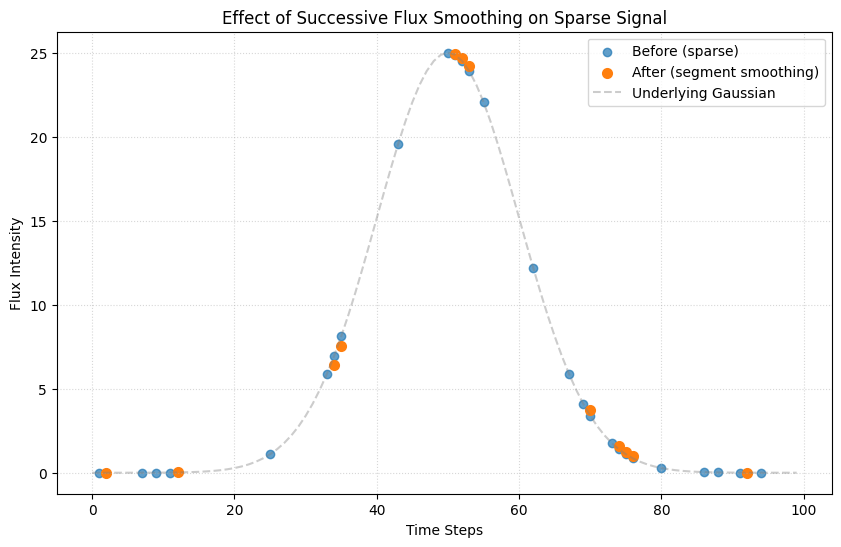

In [38]:
import numpy as np
import matplotlib.pyplot as plt

def AvgPair_aug(X, y=None, n_aug=1, balance=False):
    X_new, y_new = [], []

    for i in range(X.shape[0]):
        if balance and y is not None and y[i] != 1:
            continue

        x = X[i].astype(np.float32)

        for _ in range(n_aug):
            x_aug = np.zeros_like(x)

            for ch in range(x.shape[1]):
                nz_idx = np.where(x[:, ch] != 0)[0]

                if len(nz_idx) == 0:
                    continue

                splits = np.where(np.diff(nz_idx) != 1)[0] + 1
                segments = np.split(nz_idx, splits)

                for seg in segments:
                    if len(seg) < 2:
                        continue

                    for k in range(1, len(seg)):
                        t = seg[k]
                        t_prev = seg[k - 1]
                        x_aug[t, ch] = 0.5 * (x[t_prev, ch] + x[t, ch])

            X_new.append(x_aug)

            if y is not None:
                y_new.append(y[i])

    return np.stack(X_new), np.array(y_new)


# --- 1. Create Gaussian sparse signal ---
t = np.arange(100)
gaussian_base = 25 * np.exp(-(t - 50)**2 / (2 * 10**2))

np.random.seed(42)
mask = np.random.choice([0, 1], size=100, p=[0.7, 0.3])
sparse_data = (gaussian_base * mask).reshape(1, 100, 1)

dummy_y = np.array([1])

# --- 2. Apply augmentation ---
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Apply augmentation ---
X_aug, _ = AvgPair_aug(sparse_data, dummy_y)

orig = sparse_data[0, :, 0]
aug = X_aug[0, :, 0]

t = np.arange(len(orig))

# --- 2. Mask zeros (replace with NaN so they are not plotted) ---
orig_plot = orig.copy()
aug_plot = aug.copy()

orig_plot[orig_plot == 0] = np.nan
aug_plot[aug_plot == 0] = np.nan

# --- 3. Plot ---
plt.figure(figsize=(10, 6))

plt.scatter(t, orig_plot, label="Before (sparse)", alpha=0.7)
plt.scatter(t, aug_plot, label="After (segment smoothing)", linewidth=2)

plt.plot(t, gaussian_base, '--', color='gray', alpha=0.4, label="Underlying Gaussian")

plt.title("Effect of Successive Flux Smoothing on Sparse Signal")
plt.xlabel("Time Steps")
plt.ylabel("Flux Intensity")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.5)

plt.show()

In [41]:
import sys
sys.path.append(os.getcwd().replace("\\", "/"))

from Augmentation import (Noise_aug, filter_short_sequences, split_long_seq, GP_aug,
prepare_sequence, AvgPair_segments, ChannelDrop_aug, TimeShift_aug, TimeMask_aug, cap_long_seq,
Noise_aug_with_shift, Scale_aug)

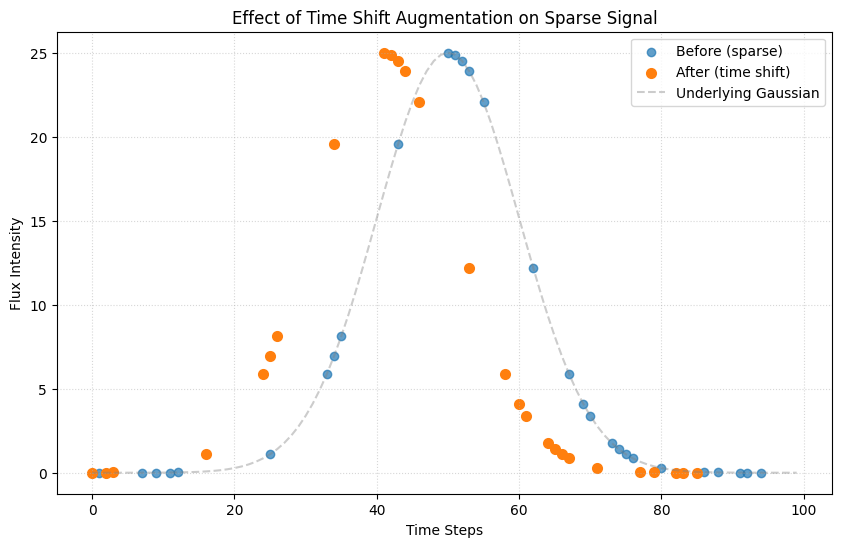

In [43]:
import numpy as np
import matplotlib.pyplot as plt

# --- Apply time shift augmentation ---
X_shift, _ = TimeShift_aug(sparse_data, dummy_y, n_aug=1)

orig = sparse_data[0, :, 0]
shifted = X_shift[0, :, 0]

t = np.arange(len(orig))

# --- Remove zeros from plot (treat as missing) ---
orig_plot = orig.copy()
shift_plot = shifted.copy()

orig_plot[orig_plot == 0] = np.nan
shift_plot[shift_plot == 0] = np.nan

# --- Plot ---
plt.figure(figsize=(10, 6))

plt.scatter(t, orig_plot, label="Before (sparse)", alpha=0.7)
plt.scatter(t, shift_plot, label="After (time shift)", linewidth=2)

plt.plot(t, gaussian_base, '--', color='gray', alpha=0.4, label="Underlying Gaussian")

plt.title("Effect of Time Shift Augmentation on Sparse Signal")
plt.xlabel("Time Steps")
plt.ylabel("Flux Intensity")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.5)

plt.show()

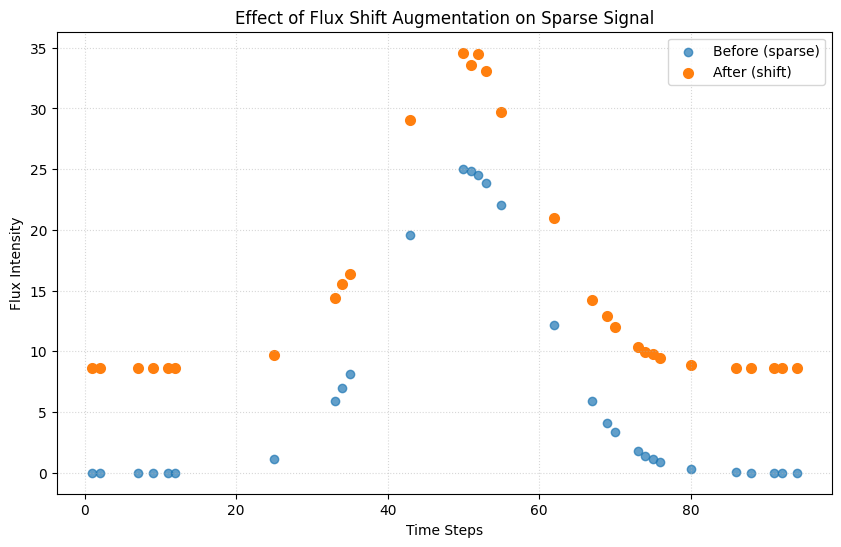

In [48]:
import numpy as np
import matplotlib.pyplot as plt

# --- Apply augmentation ---
X_aug, _ = Noise_aug_with_shift(sparse_data, dummy_y, n_aug=1)

orig = sparse_data[0, :, 0]
aug = X_aug[0, :, 0]

t = np.arange(len(orig))

# --- Remove zeros from plotting ---
orig_plot = orig.copy()
aug_plot = aug.copy()

orig_plot[orig_plot == 0] = np.nan
aug_plot[aug_plot == 0] = np.nan

# --- Plot ---
plt.figure(figsize=(10, 6))

plt.scatter(t, orig_plot, label="Before (sparse)", alpha=0.7)
plt.scatter(t, aug_plot, label="After (shift)", linewidth=2)

plt.title("Effect of Flux Shift Augmentation on Sparse Signal")
plt.xlabel("Time Steps")
plt.ylabel("Flux Intensity")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.5)

plt.show()

In [10]:
temporal_slope_df = (
    df
    .groupby("object_id")
    .apply(
        all_flux_features_per_object,
        flux_cols=flux_cols,
        include_groups=False
    )
)
total_agg = total_agg.join(temporal_slope_df)

test_temporal_slope_df = (
    df_test
    .groupby("object_id")
    .apply(
        all_flux_features_per_object,
        flux_cols=flux_cols,
        include_groups=False
    )
)
test_total_agg = test_total_agg.join(test_temporal_slope_df)

total_agg.head()

,dt,SpecType,Z,EBV,Filter_z_flux_min,Filter_z_flux_max,Filter_z_flux_mean,Filter_z_flux_std,Filter_z_flux_var,Filter_z_flux_median,...,Filter_u_flux_decay_time,Filter_u_flux_slope_pre,Filter_u_flux_slope_post,Filter_u_flux_rise_decay_ratio,Filter_u_flux_time_above_median,Filter_u_flux_duty_cycle,Filter_u_flux_post_peak_fraction,Filter_u_flux_num_peaks,Filter_u_flux_plaw_alpha,Filter_u_flux_plaw_r2
object_id,,,,,,,,,,,,,,,,,,,,,
Dornhoth_anwar_melethron,3017.1301,AGN,1.1980,0.032,98.977680,102.872637,100.203160,0.886820,0.786450,100.154410,...,854.1499,0.003725,-0.004512,1.631179,113.6701,0.500000,0.963327,3.0,0.005651,0.659290
Dornhoth_archam_grond,1709.6597,AGN,0.2260,0.016,100.281019,101.851981,100.991629,0.484553,0.234792,101.005030,...,619.1847,0.001616,-0.000673,0.773885,759.1915,0.428571,0.995883,1.0,-0.007144,0.341150
Dornhoth_certh_iaun,2265.0693,SN Ia,0.4052,0.011,98.420438,107.640174,100.669085,2.100955,4.414014,100.068011,...,2152.3169,NaN,-0.000013,0.000000,879.4682,0.500000,0.999720,3.0,-0.001463,0.109079
Dornhoth_drafn_celon,1720.4212,SN Ia,0.2748,0.132,98.756855,112.231704,100.890743,3.155021,9.954156,99.917586,...,1130.4954,0.006315,-0.001337,0.043659,406.6023,0.444444,0.985005,3.0,0.002992,0.582985
Dornhoth_fervain_onodrim,1254.2719,AGN,3.0490,0.110,97.010420,129.124111,101.476003,8.804667,77.522163,99.227388,...,787.7707,0.067152,-0.005393,0.078212,787.7707,0.400000,0.959250,1.0,NaN,NaN


In [11]:
test_total_agg.head()

,dt,Z,EBV,Filter_z_flux_min,Filter_z_flux_max,Filter_z_flux_mean,Filter_z_flux_std,Filter_z_flux_var,Filter_z_flux_median,Filter_z_flux_skew,...,Filter_u_flux_decay_time,Filter_u_flux_slope_pre,Filter_u_flux_slope_post,Filter_u_flux_rise_decay_ratio,Filter_u_flux_time_above_median,Filter_u_flux_duty_cycle,Filter_u_flux_post_peak_fraction,Filter_u_flux_num_peaks,Filter_u_flux_plaw_alpha,Filter_u_flux_plaw_r2
object_id,,,,,,,,,,,,,,,,,,,,,
Dornhoth_adar_imrath,2005.0237,0.2117,0.047,98.425702,111.995770,103.094653,4.422126,19.555196,100.548604,0.769976,...,80.6490,0.004878,-0.003211,17.583333,822.1717,0.500000,0.997580,4.0,NaN,NaN
Dornhoth_celeb_achad,2376.3608,0.8536,0.029,98.158583,104.020067,100.554762,1.615566,2.610052,100.540442,0.310912,...,1536.7726,0.001773,-0.001435,0.422780,1477.4378,0.500000,0.978146,4.0,0.010645,0.736402
Dornhoth_firion_fern,1497.4478,0.5461,0.064,99.136201,110.003349,102.249724,3.746253,14.034413,100.405293,1.355737,...,327.4163,NaN,-0.000249,0.000000,317.7864,0.500000,0.999186,0.0,-0.092632,0.491255
Dornhoth_glae_aras,2561.7451,0.6212,0.030,98.331778,102.885650,100.693572,1.042836,1.087508,100.565940,0.127973,...,496.9730,NaN,-0.003372,0.000000,323.9934,0.444444,0.983480,3.0,-0.000507,0.016378
Dornhoth_lain_tinuviel,2348.4155,0.6947,0.069,98.773825,102.937679,100.369159,0.887873,0.788319,100.349281,0.703042,...,1775.5651,0.009907,-0.002319,0.201835,955.6559,0.461538,0.960606,5.0,0.010168,0.512386


In [12]:
from IPython.display import display, HTML

def S(df, height=300):
    html = f"""
    <div style="max-height:{height}px; overflow-y:auto; overflow-x:auto;">
        {df.to_html()}
    </div>
    """
    display(HTML(html))
S(total_agg.head())

,dt,SpecType,Z,EBV,Filter_z_flux_min,Filter_z_flux_max,Filter_z_flux_mean,Filter_z_flux_std,Filter_z_flux_var,Filter_z_flux_median,Filter_z_flux_skew,Filter_z_flux_kurtosis,Filter_z_flux_n_obs,Filter_z_flux_q05,Filter_z_flux_q25,Filter_z_flux_q75,Filter_z_flux_q95,Filter_z_flux_iqr,Filter_z_flux_mad,Filter_z_flux_max_change,Filter_z_flux_rise_time,Filter_z_flux_decay_time,Filter_z_flux_slope_pre,Filter_z_flux_slope_post,Filter_z_flux_rise_decay_ratio,Filter_z_flux_time_above_median,Filter_z_flux_duty_cycle,Filter_z_flux_post_peak_fraction,Filter_z_flux_num_peaks,Filter_z_flux_plaw_alpha,Filter_z_flux_plaw_r2,Filter_r_flux_min,Filter_r_flux_max,Filter_r_flux_mean,Filter_r_flux_std,Filter_r_flux_var,Filter_r_flux_median,Filter_r_flux_skew,Filter_r_flux_kurtosis,Filter_r_flux_n_obs,Filter_r_flux_q05,Filter_r_flux_q25,Filter_r_flux_q75,Filter_r_flux_q95,Filter_r_flux_iqr,Filter_r_flux_mad,Filter_r_flux_max_change,Filter_r_flux_rise_time,Filter_r_flux_decay_time,Filter_r_flux_slope_pre,Filter_r_flux_slope_post,Filter_r_flux_rise_decay_ratio,Filter_r_flux_time_above_median,Filter_r_flux_duty_cycle,Filter_r_flux_post_peak_fraction,Filter_r_flux_num_peaks,Filter_r_flux_plaw_alpha,Filter_r_flux_plaw_r2,Filter_y_flux_min,Filter_y_flux_max,Filter_y_flux_mean,Filter_y_flux_std,Filter_y_flux_var,Filter_y_flux_median,Filter_y_flux_skew,Filter_y_flux_kurtosis,Filter_y_flux_n_obs,Filter_y_flux_q05,Filter_y_flux_q25,Filter_y_flux_q75,Filter_y_flux_q95,Filter_y_flux_iqr,Filter_y_flux_mad,Filter_y_flux_max_change,Filter_y_flux_rise_time,Filter_y_flux_decay_time,Filter_y_flux_slope_pre,Filter_y_flux_slope_post,Filter_y_flux_rise_decay_ratio,Filter_y_flux_time_above_median,Filter_y_flux_duty_cycle,Filter_y_flux_post_peak_fraction,Filter_y_flux_num_peaks,Filter_y_flux_plaw_alpha,Filter_y_flux_plaw_r2,Filter_i_flux_min,Filter_i_flux_max,Filter_i_flux_mean,Filter_i_flux_std,Filter_i_flux_var,Filter_i_flux_median,Filter_i_flux_skew,Filter_i_flux_kurtosis,Filter_i_flux_n_obs,Filter_i_flux_q05,Filter_i_flux_q25,Filter_i_flux_q75,Filter_i_flux_q95,Filter_i_flux_iqr,Filter_i_flux_mad,Filter_i_flux_max_change,Filter_i_flux_rise_time,Filter_i_flux_decay_time,Filter_i_flux_slope_pre,Filter_i_flux_slope_post,Filter_i_flux_rise_decay_ratio,Filter_i_flux_time_above_median,Filter_i_flux_duty_cycle,Filter_i_flux_post_peak_fraction,Filter_i_flux_num_peaks,Filter_i_flux_plaw_alpha,Filter_i_flux_plaw_r2,Filter_g_flux_min,Filter_g_flux_max,Filter_g_flux_mean,Filter_g_flux_std,Filter_g_flux_var,Filter_g_flux_median,Filter_g_flux_skew,Filter_g_flux_kurtosis,Filter_g_flux_n_obs,Filter_g_flux_q05,Filter_g_flux_q25,Filter_g_flux_q75,Filter_g_flux_q95,Filter_g_flux_iqr,Filter_g_flux_mad,Filter_g_flux_max_change,Filter_g_flux_rise_time,Filter_g_flux_decay_time,Filter_g_flux_slope_pre,Filter_g_flux_slope_post,Filter_g_flux_rise_decay_ratio,Filter_g_flux_time_above_median,Filter_g_flux_duty_cycle,Filter_g_flux_post_peak_fraction,Filter_g_flux_num_peaks,Filter_g_flux_plaw_alpha,Filter_g_flux_plaw_r2,Filter_u_flux_min,Filter_u_flux_max,Filter_u_flux_mean,Filter_u_flux_std,Filter_u_flux_var,Filter_u_flux_median,Filter_u_flux_skew,Filter_u_flux_kurtosis,Filter_u_flux_n_obs,Filter_u_flux_q05,Filter_u_flux_q25,Filter_u_flux_q75,Filter_u_flux_q95,Filter_u_flux_iqr,Filter_u_flux_mad,Filter_u_flux_max_change,Filter_u_flux_rise_time,Filter_u_flux_decay_time,Filter_u_flux_slope_pre,Filter_u_flux_slope_post,Filter_u_flux_rise_decay_ratio,Filter_u_flux_time_above_median,Filter_u_flux_duty_cycle,Filter_u_flux_post_peak_fraction,Filter_u_flux_num_peaks,Filter_u_flux_plaw_alpha,Filter_u_flux_plaw_r2
object_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Dornhoth_anwar_melethron,3017.1301,AGN,1.1980,0.032,98.977680,102.872637,100.203160,0.886820,0.786450,100.154410,0.814946,0.811264,36.0,99.062097,99.431622,100.808152,101.520118,1.376530,1.087134,0.284608,1432.2436,1237.380

In [13]:
from IPython.display import display, HTML

def S(df, height=300):
    html = f"""
    <div style="max-height:{height}px; overflow-y:auto; overflow-x:auto;">
        {df.to_html()}
    </div>
    """
    display(HTML(html))
S(test_total_agg.head())

,dt,Z,EBV,Filter_z_flux_min,Filter_z_flux_max,Filter_z_flux_mean,Filter_z_flux_std,Filter_z_flux_var,Filter_z_flux_median,Filter_z_flux_skew,Filter_z_flux_kurtosis,Filter_z_flux_n_obs,Filter_z_flux_q05,Filter_z_flux_q25,Filter_z_flux_q75,Filter_z_flux_q95,Filter_z_flux_iqr,Filter_z_flux_mad,Filter_z_flux_max_change,Filter_z_flux_rise_time,Filter_z_flux_decay_time,Filter_z_flux_slope_pre,Filter_z_flux_slope_post,Filter_z_flux_rise_decay_ratio,Filter_z_flux_time_above_median,Filter_z_flux_duty_cycle,Filter_z_flux_post_peak_fraction,Filter_z_flux_num_peaks,Filter_z_flux_plaw_alpha,Filter_z_flux_plaw_r2,Filter_r_flux_min,Filter_r_flux_max,Filter_r_flux_mean,Filter_r_flux_std,Filter_r_flux_var,Filter_r_flux_median,Filter_r_flux_skew,Filter_r_flux_kurtosis,Filter_r_flux_n_obs,Filter_r_flux_q05,Filter_r_flux_q25,Filter_r_flux_q75,Filter_r_flux_q95,Filter_r_flux_iqr,Filter_r_flux_mad,Filter_r_flux_max_change,Filter_r_flux_rise_time,Filter_r_flux_decay_time,Filter_r_flux_slope_pre,Filter_r_flux_slope_post,Filter_r_flux_rise_decay_ratio,Filter_r_flux_time_above_median,Filter_r_flux_duty_cycle,Filter_r_flux_post_peak_fraction,Filter_r_flux_num_peaks,Filter_r_flux_plaw_alpha,Filter_r_flux_plaw_r2,Filter_y_flux_min,Filter_y_flux_max,Filter_y_flux_mean,Filter_y_flux_std,Filter_y_flux_var,Filter_y_flux_median,Filter_y_flux_skew,Filter_y_flux_kurtosis,Filter_y_flux_n_obs,Filter_y_flux_q05,Filter_y_flux_q25,Filter_y_flux_q75,Filter_y_flux_q95,Filter_y_flux_iqr,Filter_y_flux_mad,Filter_y_flux_max_change,Filter_y_flux_rise_time,Filter_y_flux_decay_time,Filter_y_flux_slope_pre,Filter_y_flux_slope_post,Filter_y_flux_rise_decay_ratio,Filter_y_flux_time_above_median,Filter_y_flux_duty_cycle,Filter_y_flux_post_peak_fraction,Filter_y_flux_num_peaks,Filter_y_flux_plaw_alpha,Filter_y_flux_plaw_r2,Filter_i_flux_min,Filter_i_flux_max,Filter_i_flux_mean,Filter_i_flux_std,Filter_i_flux_var,Filter_i_flux_median,Filter_i_flux_skew,Filter_i_flux_kurtosis,Filter_i_flux_n_obs,Filter_i_flux_q05,Filter_i_flux_q25,Filter_i_flux_q75,Filter_i_flux_q95,Filter_i_flux_iqr,Filter_i_flux_mad,Filter_i_flux_max_change,Filter_i_flux_rise_time,Filter_i_flux_decay_time,Filter_i_flux_slope_pre,Filter_i_flux_slope_post,Filter_i_flux_rise_decay_ratio,Filter_i_flux_time_above_median,Filter_i_flux_duty_cycle,Filter_i_flux_post_peak_fraction,Filter_i_flux_num_peaks,Filter_i_flux_plaw_alpha,Filter_i_flux_plaw_r2,Filter_g_flux_min,Filter_g_flux_max,Filter_g_flux_mean,Filter_g_flux_std,Filter_g_flux_var,Filter_g_flux_median,Filter_g_flux_skew,Filter_g_flux_kurtosis,Filter_g_flux_n_obs,Filter_g_flux_q05,Filter_g_flux_q25,Filter_g_flux_q75,Filter_g_flux_q95,Filter_g_flux_iqr,Filter_g_flux_mad,Filter_g_flux_max_change,Filter_g_flux_rise_time,Filter_g_flux_decay_time,Filter_g_flux_slope_pre,Filter_g_flux_slope_post,Filter_g_flux_rise_decay_ratio,Filter_g_flux_time_above_median,Filter_g_flux_duty_cycle,Filter_g_flux_post_peak_fraction,Filter_g_flux_num_peaks,Filter_g_flux_plaw_alpha,Filter_g_flux_plaw_r2,Filter_u_flux_min,Filter_u_flux_max,Filter_u_flux_mean,Filter_u_flux_std,Filter_u_flux_var,Filter_u_flux_median,Filter_u_flux_skew,Filter_u_flux_kurtosis,Filter_u_flux_n_obs,Filter_u_flux_q05,Filter_u_flux_q25,Filter_u_flux_q75,Filter_u_flux_q95,Filter_u_flux_iqr,Filter_u_flux_mad,Filter_u_flux_max_change,Filter_u_flux_rise_time,Filter_u_flux_decay_time,Filter_u_flux_slope_pre,Filter_u_flux_slope_post,Filter_u_flux_rise_decay_ratio,Filter_u_flux_time_above_median,Filter_u_flux_duty_cycle,Filter_u_flux_post_peak_fraction,Filter_u_flux_num_peaks,Filter_u_flux_plaw_alpha,Filter_u_flux_plaw_r2
object_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Dornhoth_adar_imrath,2005.0237,0.2117,0.047,98.425702,111.995770,103.094653,4.422126,19.555196,100.548604,0.769976,-1.030983,43.0,99.238497,99.661753,107.224557,111.161895,7.562804,1.771444,0.347723,1462.8832,542.1405,0.009276,-0.012

In [14]:
# transient_map = {
#     "SN Ia":0, "SN Ia-91T-like":0, "SN Ia-91bg-like":0, "SN Iax[02cx-like]":0, "SN Ia-pec": 0,
#     "SN Ib": 1, "SN Ib/c": 1, "SN Ic": 1, "SN Ic-BL": 1,
#     "SN II": 2, "SN IIP": 2, "SN IIn": 2, "SN IIb":2,
#     "SLSN-I": 3, "SLSN-II": 3,
#     "AGN": 4, "TDE": 5
# }
# en = LabelEncoder()

In [15]:
target = "SpecType"
cols = total_agg.drop(columns=target).columns
sc = StandardScaler()

df_train = total_agg.copy()
df_train[cols] = sc.fit_transform(df_train[cols])
df_train["SpecType"] = (df_train["SpecType"] == "TDE").astype(int)

df_test = test_total_agg.copy()
df_test[cols] = sc.transform(df_test[cols])

In [16]:
df_train.isnull().sum()[lambda x: x>100]

Filter_z_flux_slope_post           118
Filter_z_flux_rise_decay_ratio     118
Filter_z_flux_plaw_alpha           345
Filter_z_flux_plaw_r2              345
Filter_r_flux_slope_post           134
Filter_r_flux_rise_decay_ratio     134
Filter_r_flux_plaw_alpha           298
Filter_r_flux_plaw_r2              298
Filter_y_flux_slope_post           214
Filter_y_flux_rise_decay_ratio     214
Filter_y_flux_plaw_alpha           545
Filter_y_flux_plaw_r2              545
Filter_i_flux_slope_post           128
Filter_i_flux_rise_decay_ratio     128
Filter_i_flux_plaw_alpha           315
Filter_i_flux_plaw_r2              315
Filter_g_flux_slope_pre            132
Filter_g_flux_slope_post           295
Filter_g_flux_rise_decay_ratio     295
Filter_g_flux_plaw_alpha           788
Filter_g_flux_plaw_r2              788
Filter_u_flux_slope_pre            234
Filter_u_flux_slope_post           424
Filter_u_flux_rise_decay_ratio     424
Filter_u_flux_plaw_alpha          1058
Filter_u_flux_plaw_r2    

In [17]:
from IPython.display import display, HTML

def S(df, height=300):
    html = f"""
    <div style="max-height:{height}px; overflow-y:auto; overflow-x:auto;">
        {df.to_html()}
    </div>
    """
    display(HTML(html))
S(df_train.head())

,dt,SpecType,Z,EBV,Filter_z_flux_min,Filter_z_flux_max,Filter_z_flux_mean,Filter_z_flux_std,Filter_z_flux_var,Filter_z_flux_median,Filter_z_flux_skew,Filter_z_flux_kurtosis,Filter_z_flux_n_obs,Filter_z_flux_q05,Filter_z_flux_q25,Filter_z_flux_q75,Filter_z_flux_q95,Filter_z_flux_iqr,Filter_z_flux_mad,Filter_z_flux_max_change,Filter_z_flux_rise_time,Filter_z_flux_decay_time,Filter_z_flux_slope_pre,Filter_z_flux_slope_post,Filter_z_flux_rise_decay_ratio,Filter_z_flux_time_above_median,Filter_z_flux_duty_cycle,Filter_z_flux_post_peak_fraction,Filter_z_flux_num_peaks,Filter_z_flux_plaw_alpha,Filter_z_flux_plaw_r2,Filter_r_flux_min,Filter_r_flux_max,Filter_r_flux_mean,Filter_r_flux_std,Filter_r_flux_var,Filter_r_flux_median,Filter_r_flux_skew,Filter_r_flux_kurtosis,Filter_r_flux_n_obs,Filter_r_flux_q05,Filter_r_flux_q25,Filter_r_flux_q75,Filter_r_flux_q95,Filter_r_flux_iqr,Filter_r_flux_mad,Filter_r_flux_max_change,Filter_r_flux_rise_time,Filter_r_flux_decay_time,Filter_r_flux_slope_pre,Filter_r_flux_slope_post,Filter_r_flux_rise_decay_ratio,Filter_r_flux_time_above_median,Filter_r_flux_duty_cycle,Filter_r_flux_post_peak_fraction,Filter_r_flux_num_peaks,Filter_r_flux_plaw_alpha,Filter_r_flux_plaw_r2,Filter_y_flux_min,Filter_y_flux_max,Filter_y_flux_mean,Filter_y_flux_std,Filter_y_flux_var,Filter_y_flux_median,Filter_y_flux_skew,Filter_y_flux_kurtosis,Filter_y_flux_n_obs,Filter_y_flux_q05,Filter_y_flux_q25,Filter_y_flux_q75,Filter_y_flux_q95,Filter_y_flux_iqr,Filter_y_flux_mad,Filter_y_flux_max_change,Filter_y_flux_rise_time,Filter_y_flux_decay_time,Filter_y_flux_slope_pre,Filter_y_flux_slope_post,Filter_y_flux_rise_decay_ratio,Filter_y_flux_time_above_median,Filter_y_flux_duty_cycle,Filter_y_flux_post_peak_fraction,Filter_y_flux_num_peaks,Filter_y_flux_plaw_alpha,Filter_y_flux_plaw_r2,Filter_i_flux_min,Filter_i_flux_max,Filter_i_flux_mean,Filter_i_flux_std,Filter_i_flux_var,Filter_i_flux_median,Filter_i_flux_skew,Filter_i_flux_kurtosis,Filter_i_flux_n_obs,Filter_i_flux_q05,Filter_i_flux_q25,Filter_i_flux_q75,Filter_i_flux_q95,Filter_i_flux_iqr,Filter_i_flux_mad,Filter_i_flux_max_change,Filter_i_flux_rise_time,Filter_i_flux_decay_time,Filter_i_flux_slope_pre,Filter_i_flux_slope_post,Filter_i_flux_rise_decay_ratio,Filter_i_flux_time_above_median,Filter_i_flux_duty_cycle,Filter_i_flux_post_peak_fraction,Filter_i_flux_num_peaks,Filter_i_flux_plaw_alpha,Filter_i_flux_plaw_r2,Filter_g_flux_min,Filter_g_flux_max,Filter_g_flux_mean,Filter_g_flux_std,Filter_g_flux_var,Filter_g_flux_median,Filter_g_flux_skew,Filter_g_flux_kurtosis,Filter_g_flux_n_obs,Filter_g_flux_q05,Filter_g_flux_q25,Filter_g_flux_q75,Filter_g_flux_q95,Filter_g_flux_iqr,Filter_g_flux_mad,Filter_g_flux_max_change,Filter_g_flux_rise_time,Filter_g_flux_decay_time,Filter_g_flux_slope_pre,Filter_g_flux_slope_post,Filter_g_flux_rise_decay_ratio,Filter_g_flux_time_above_median,Filter_g_flux_duty_cycle,Filter_g_flux_post_peak_fraction,Filter_g_flux_num_peaks,Filter_g_flux_plaw_alpha,Filter_g_flux_plaw_r2,Filter_u_flux_min,Filter_u_flux_max,Filter_u_flux_mean,Filter_u_flux_std,Filter_u_flux_var,Filter_u_flux_median,Filter_u_flux_skew,Filter_u_flux_kurtosis,Filter_u_flux_n_obs,Filter_u_flux_q05,Filter_u_flux_q25,Filter_u_flux_q75,Filter_u_flux_q95,Filter_u_flux_iqr,Filter_u_flux_mad,Filter_u_flux_max_change,Filter_u_flux_rise_time,Filter_u_flux_decay_time,Filter_u_flux_slope_pre,Filter_u_flux_slope_post,Filter_u_flux_rise_decay_ratio,Filter_u_flux_time_above_median,Filter_u_flux_duty_cycle,Filter_u_flux_post_peak_fraction,Filter_u_flux_num_peaks,Filter_u_flux_plaw_alpha,Filter_u_flux_plaw_r2
object_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Dornhoth_anwar_melethron,1.648297,0,0.978015,-0.383881,0.410801,-0.391880,-0.393167,-0.482673,-0.210386,-0.275292,-0.003060,-0.325914,0.199846,0.048308,-0.313919,-0.295158,-0.514885,-0.127314,-0.005714,-0.435121,0.370134,0.

In [18]:
X_train, X_test, y_train, y_test = train_test_split(df_train[cols],df_train[target],test_size=0.3,stratify=df_train[target], random_state =42)
weight = 0.45
model = XGBClassifier(scale_pos_weight=weight, random_state=42, objective="binary:logistic")
model.fit(X_train,y_train)
pred = model.predict_proba(X_test)[:,1]

aucpr = average_precision_score(y_test,pred)
print(aucpr)

0.38970643870819327


<Figure size 800x600 with 0 Axes>

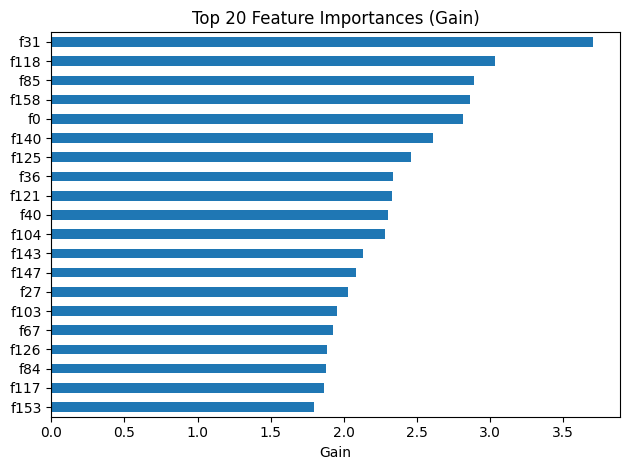

In [19]:
# get feature importance by gain
importance = model.get_booster().get_score(importance_type="gain")

# convert to DataFrame
imp_df = (
    pd.DataFrame.from_dict(importance, orient="index", columns=["gain"])
    .sort_values("gain", ascending=False)
    .head(20)
)

# plot
plt.figure(figsize=(8, 6))
imp_df[::-1].plot(kind="barh", legend=False)
plt.xlabel("Gain")
plt.title("Top 20 Feature Importances (Gain)")
plt.tight_layout()
plt.show()

In [20]:
scores = []
max_f1 = 0
best_thr = 0
for t in np.linspace(0.001, 0.15, 400):
    f1 = f1_score(y_test, pred > t)
    scores.append(f"thr {t:.3f}: f1 {f1:.3f}")
    if f1 > max_f1:
        max_f1 = f1
        best_thr = t

print(f"Best F1: {max_f1:.3f} at threshold {best_thr:.4f}")

Best F1: 0.460 at threshold 0.0238


In [21]:
# Final submission
y_pred_prob = model.predict_proba(df_test)[:,1]
y_pred = (y_pred_prob > best_thr).astype(int).flatten()

object_ids = df_test.groupby("object_id").first().index
sub = pd.DataFrame({
    "object_id": object_ids,
    "prediction": y_pred
})
sub.to_csv(f"{os.getcwd().replace("\\", "/")}/submission/XGB_submission.csv", index=False)
sub.head()

,object_id,prediction
0,Dornhoth_adar_imrath,0
1,Dornhoth_celeb_achad,0
2,Dornhoth_firion_fern,0
3,Dornhoth_glae_aras,1
4,Dornhoth_lain_tinuviel,1


In [22]:
from catboost import CatBoostClassifier

model = CatBoostClassifier(verbose=0)
model.fit(X_train, y_train)
pred = model.predict_proba(X_test)[:,1]
aucpr = average_precision_score(y_test,pred)
print(aucpr)

0.4423415912705981


In [23]:
scores = []
max_f1 = 0
best_thr = 0
for t in np.linspace(0.001, 0.15, 400):
    f1 = f1_score(y_test, pred > t)
    scores.append(f"thr {t:.3f}: f1 {f1:.3f}")
    if f1 > max_f1:
        max_f1 = f1
        best_thr = t

print(f"Best F1: {max_f1:.3f} at threshold {best_thr:.4f}")

Best F1: 0.514 at threshold 0.0787


In [24]:
# Final submission
y_pred_prob = model.predict_proba(df_test)[:,1]
y_pred = (y_pred_prob > best_thr).astype(int).flatten()

object_ids = df_test.groupby("object_id").first().index
sub = pd.DataFrame({
    "object_id": object_ids,
    "prediction": y_pred
})
sub.to_csv(f"{os.getcwd().replace("\\", "/")}/submission/catboost_submission.csv", index=False)
sub.head()

,object_id,prediction
0,Dornhoth_adar_imrath,0
1,Dornhoth_celeb_achad,0
2,Dornhoth_firion_fern,0
3,Dornhoth_glae_aras,1
4,Dornhoth_lain_tinuviel,1


In [25]:
X_train.head()

,dt,Z,EBV,Filter_z_flux_min,Filter_z_flux_max,Filter_z_flux_mean,Filter_z_flux_std,Filter_z_flux_var,Filter_z_flux_median,Filter_z_flux_skew,...,Filter_u_flux_decay_time,Filter_u_flux_slope_pre,Filter_u_flux_slope_post,Filter_u_flux_rise_decay_ratio,Filter_u_flux_time_above_median,Filter_u_flux_duty_cycle,Filter_u_flux_post_peak_fraction,Filter_u_flux_num_peaks,Filter_u_flux_plaw_alpha,Filter_u_flux_plaw_r2
object_id,,,,,,,,,,,,,,,,,,,,,
forodrim_lossen_ruith,-1.032044,1.332256,0.203023,0.802341,-0.060682,1.000071,-0.169353,-0.153708,1.397769,-1.295802,...,0.517112,-0.137500,0.139433,-0.200240,-0.377407,-1.796783,0.231202,-0.344421,NaN,NaN
lebdas_curunir_cugu,-0.953995,-0.487359,-0.367578,0.290093,0.593164,-0.019571,0.347995,-0.011229,-0.346329,1.277218,...,0.332854,-0.097476,0.145692,-0.203571,-0.492403,-1.210831,0.407242,-0.344421,-0.125085,-0.793567
hun_pilin_mindon,1.724664,1.308146,-0.334973,-0.446704,-0.144571,-0.176991,-0.232106,-0.166848,-0.292783,0.098096,...,1.752036,-0.189790,0.146427,-0.195539,0.490789,-1.210831,0.247711,-0.344421,0.017360,0.211541
daen_glaur_ram,-1.781726,-0.651311,-0.465396,0.366290,0.041788,-0.149225,-0.155577,-0.150703,-0.147760,0.945173,...,-0.682292,-0.047408,0.076294,-0.188139,-1.697757,-1.796783,0.009859,-0.533521,0.015152,1.955090
maethor_glass_edlothiad,-0.902076,-0.268879,-0.661031,0.359964,-0.404251,-0.302843,-0.356941,-0.190325,-0.273953,-0.138420,...,-1.251995,-0.202524,NaN,NaN,-1.122413,-0.579807,0.623629,0.033777,NaN,NaN


In [26]:
X_train.fillna(0, inplace=True)
X_test.fillna(0, inplace=True)
X_test.head()

,dt,Z,EBV,Filter_z_flux_min,Filter_z_flux_max,Filter_z_flux_mean,Filter_z_flux_std,Filter_z_flux_var,Filter_z_flux_median,Filter_z_flux_skew,...,Filter_u_flux_decay_time,Filter_u_flux_slope_pre,Filter_u_flux_slope_post,Filter_u_flux_rise_decay_ratio,Filter_u_flux_time_above_median,Filter_u_flux_duty_cycle,Filter_u_flux_post_peak_fraction,Filter_u_flux_num_peaks,Filter_u_flux_plaw_alpha,Filter_u_flux_plaw_r2
object_id,,,,,,,,,,,,,,,,,,,,,
bragol_galenas_raug,0.456893,-0.369773,-0.677333,-0.860968,-0.494901,-0.483978,-0.509081,-0.214142,-0.344912,-0.902406,...,0.648607,-0.174832,0.147742,-0.192317,-1.408835,0.840000,0.417173,0.222876,-0.090236,-0.983509
achas_eilian_lossen,-0.940339,-0.855881,-0.709939,0.298197,-0.298698,-0.278585,-0.386088,-0.195295,-0.159453,0.232257,...,-0.002375,-0.144732,0.135027,-0.188437,-0.911281,0.840000,0.274898,-0.344421,-0.057763,-0.436504
raef_min_ram,0.335350,0.352435,-0.546910,-0.853696,-0.459167,-0.517356,-0.230840,-0.166592,-0.423133,-0.687734,...,0.649371,-0.158731,0.117743,-0.190169,2.226610,0.840000,-0.353768,-0.344421,0.065393,1.026040
haeron_angos_cugu,-1.285648,-0.628685,-0.514305,0.563452,-0.194969,-0.070882,-0.393360,-0.196506,-0.076097,0.878821,...,-0.868309,-0.180713,0.097531,-0.134210,-1.379210,-2.851496,0.320115,-0.533521,0.000000,0.000000
mund_rudh_saig,-1.342572,-0.427638,-0.481699,0.105942,-0.484660,0.066594,-0.401532,-0.197851,0.316178,-1.146739,...,-0.813998,-0.192115,0.129800,-0.136513,-0.848809,-1.210831,0.469260,-0.344421,0.000000,0.000000


In [27]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Input, LSTM, Dense, Dropout, Bidirectional, 
                                     Conv1D, MaxPooling1D, GlobalAveragePooling1D,
                                     BatchNormalization, Activation, Add, 
                                     LayerNormalization, MultiHeadAttention, 
                                     AveragePooling1D, Concatenate, Lambda, LeakyReLU)
import tensorflow as tf
from sklearn.utils import class_weight
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(6128, activation=LeakyReLU()),
    Dropout(0.4),
    
    Dense(64, activation='relu'),
    Dropout(0.4),
    
    Dense(16, activation='relu'),
    Dropout(0.4),

    Dense(1, activation="sigmoid")
])

# Create class weights to help the model handle data imbalance
classes = np.unique(y_train)
weights = class_weight.compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights = dict(zip(classes, weights))

early_stop = EarlyStopping(
        monitor="val_aucpr",
        patience=50,
        verbose=1,
        restore_best_weights=True,
        start_from_epoch=5,
)

model.compile(
    optimizer=Adam(
        learning_rate=0.0001,
        gradient_accumulation_steps=12
    ),
    loss="binary_crossentropy",
    metrics=[tf.keras.metrics.AUC(curve="PR", name="aucpr")]
)

history = model.fit(
    X_train,
    y_train,
    epochs=200,
    batch_size=16,
    validation_data=(X_test, y_test),
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
134/134 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - aucpr: 0.0550 - loss: 0.7009 - val_aucpr: 0.1245 - val_loss: 0.5748
Epoch 2/200
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - aucpr: 0.1197 - loss: 0.6398 - val_aucpr: 0.1642 - val_loss: 0.5262
Epoch 3/200
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - aucpr: 0.1407 - loss: 0.6088 - val_aucpr: 0.1816 - val_loss: 0.4920
Epoch 4/200
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - aucpr: 0.1465 - loss: 0.5822 - val_aucpr: 0.1923 - val_loss: 0.4666
Epoch 5/200
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - aucpr: 0.1487 - loss: 0.5699 - val_aucpr: 0.2073 - val_loss: 0.4617
Epoch 6/200
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - aucpr: 0.1582 - loss: 0.5490 - val_aucpr: 0.2136 - val_loss: 0.4427
Epoch 7/200
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - aucpr: 0.2175 - loss: 0.5220 - val_aucpr: 0.2225 - val_loss: 0.4395
Epoch 8/200
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - aucpr: 0.2365 - loss: 0.5073 - val_aucpr: 0.2393 - val_loss: 0.4357
Epoch 9/200
134

max val_aucpr 0.36


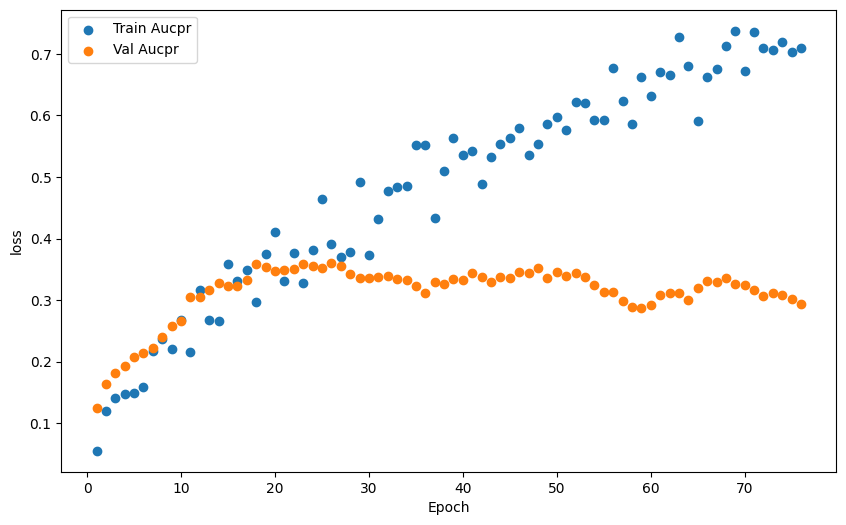

In [28]:
epochs = range(1, len(history.history["aucpr"]) + 1)
min_loss = max(history.history["val_aucpr"])
print(f"max val_aucpr {round(min_loss,3)}")
plt.figure(figsize=(10, 6))
plt.scatter(epochs, history.history["aucpr"], label="Train Aucpr")
plt.scatter(epochs, history.history["val_aucpr"], label="Val Aucpr")
plt.xlabel("Epoch")
plt.ylabel("loss")
plt.legend()
plt.show()

In [29]:
# scores = []
# max_f1 = 0
# best_thr = 0
# for t in np.linspace(0.001, 0.15, 400):
#     f1 = f1_score(y_test, pred > t)
#     scores.append(f"thr {t:.3f}: f1 {f1:.3f}")
#     if f1 > max_f1:
#         max_f1 = f1
#         best_thr = t

# print(f"Best F1: {max_f1:.3f} at threshold {best_thr:.4f}")

In [30]:
# print(balanced_accuracy_score(y_test,pred))

In [31]:
# from sklearn.ensemble import RandomForestClassifier

# model = RandomForestClassifier(n_estimators=10000,n_jobs=-1)
# model.fit(X_train, y_train)
# pred = model.predict_proba(X_test)[:,1]
# aucpr = average_precision_score(y_test,pred)
# print(aucpr)

In [32]:
# from lightgbm import LGBMClassifier

# model = LGBMClassifier(verbose=0)
# model.fit(X_train, y_train)
# pred = model.predict_proba(X_test)[:,1]
# aucpr = average_precision_score(y_test,pred)
# print(aucpr)